# Corrective Retrieval — Catching Bad Hits, Falling Back to Web

## What problem does this solve?

Self-RAG decides per passage. CRAG asks a different question: when retrieval *as a whole* failed, what do we do? The vanilla pipeline answers from bad context anyway. CRAG triggers a fallback — usually a web search — and incorporates the new evidence.
Concretely: an evaluator scores the retrieved passages. If the best is above a threshold, use them. If the worst is below another threshold, ignore retrieval entirely and search the web. If they sit in between, decompose and combine. The three-way split lets the system stay grounded in the corpus when it can and reach beyond when it must.

## Where it came from

CRAG was published in early 2024 by Yan et al. (Tencent + Tsinghua). Their main contribution was a lightweight T5-based evaluator that scored retrieval quality and routed to one of three branches: correct (use), incorrect (web fallback), ambiguous (decompose). They showed 4–10 point improvements on PopQA and Biography depending on the base model.
By mid-2025 the pattern had spread widely. Production systems use it with Tavily, Brave Search, or Exa as the web fallback; the prompt-engineered variant replaces the T5 evaluator with a small LLM. We use the prompt-engineered variant and mock the web fallback so the notebook runs deterministically.

## Where it fits in the RAG landscape

CRAG sits between Self-RAG and Agentic RAG in the decision hierarchy:

- **Self-RAG (Recipe 24)** decides yes/no per passage.
- **CRAG (this recipe)** decides good/borderline/bad over the whole retrieval, then routes.
- **Agentic RAG (Recipe 28)** lets the model loop — retrieve, critique, re-query, retry. CRAG is one step of an agentic loop; LangGraph wraps the loop.

All three can stack. Many production systems run Adaptive-RAG (Recipe 26) to classify the question, then CRAG to check whether retrieval covered it, then Self-RAG to filter the surviving passages. The cost is real; the quality lift on broad domains is real too.

## When to use it (and when not to)

Use CRAG when your corpus is good but incomplete. The classic example: a customer support agent whose retrieval covers 80 % of common questions but misses recent product changes. CRAG keeps the 80 % grounded in the corpus and reaches the web for the 20 %.
Skip it when web access is not allowed (regulated industries, air-gapped deployments). The structure still works — you can fall back to a different internal corpus, or to an LLM with explicit "I do not know" instructions — but the value drops sharply.
Skip it also when retrieval recall is the bottleneck rather than retrieval correctness. If you cannot find anything good in the corpus because retrieval is broken (wrong embedder, wrong chunks), fix the retrieval before adding CRAG. CRAG is not a substitute for working retrieval.

## The intuition

Three intuitions:

**Two thresholds, not one.** A single "is the retrieval good" classifier loses information. The good/borderline/bad three-way split — high threshold for "trust completely", low threshold for "abandon" — degrades gracefully into the ambiguous middle.

**Web search is a different distribution.** Web results are a fresh-but-noisy distribution. A confident integration prompt ("use these web snippets, do not speculate") matters more than for in-corpus results because the model is more tempted to over-summarise web noise.

**The evaluator is cheap.** It does not need to be smart, only consistent. A small fast model scoring "how relevant is this passage to this question on a 0-1 scale" is fine. The fine-tuned T5 in the original paper is overkill for most teams.

## Architecture

```mermaid
flowchart TB
  Q[User question] --> R[Retrieve top-k]
  R --> E[Evaluator<br/>score each passage]
  E --> S{Best score?}
  S -->|high<br/>>= 0.7| GOOD[Use corpus only]
  S -->|low<br/>< 0.3| BAD[Web search<br/>only]
  S -->|middle| MIX[Use corpus<br/>+ web snippets]
  GOOD --> GEN[LLM answer]
  BAD --> GEN
  MIX --> GEN
  GEN --> OUT[Return answer]
```

## References

- 📄 [CRAG: Corrective Retrieval Augmented Generation](https://arxiv.org/abs/2401.15884) — Yan et al., 2024. The paper that introduced the pattern.
- 📚 [LangGraph CRAG tutorial](https://langchain-ai.github.io/langgraph/tutorials/rag/langgraph_crag/) — Reference implementation as a stateful graph.
- 📚 [Tavily Search API](https://tavily.com/docs) — The web-search API most CRAG implementations target.
- 📄 [Self-RAG paper (cousin technique)](https://arxiv.org/abs/2310.11511) — Per-passage filtering; covered in Recipe 24.
- 📄 [Adaptive-RAG paper (cousin technique)](https://arxiv.org/abs/2403.14403) — Pre-retrieval routing; covered in Recipe 26.
- 📚 [Exa Search API](https://docs.exa.ai/) — Alternative web-search API often used in CRAG.

## Setup

Pick a provider via the `PROVIDER` env var; everything below is provider-agnostic. The default is Nebius. Tracing is off by default in published notebooks so the outputs are clean — flip `COOKBOOK_TRACING=phoenix` to send spans to a local Phoenix UI.

In [1]:
import os
os.environ.setdefault('PROVIDER', 'nebius')
os.environ.setdefault('COOKBOOK_TRACING', 'off')

from cookbook.providers import LLMClient
from cookbook.tracing import init_tracing

client = LLMClient()
print(f'Provider: {client.provider}  |  Chat model: {client.chat_model}')
print(init_tracing())

Provider: nebius  |  Chat model: meta-llama/Llama-3.3-70B-Instruct
Tracing disabled.


## Build the Pipeline, Step by Step

### Step 1 — Index the corpus

We use the arXiv Mamba survey. It is a long technical paper; we expect retrieval to be good for questions inside the paper and bad for questions adjacent to it (about earlier S4 models, about non-SSM techniques the paper does not cover). That mix is what CRAG exists to handle.

In [2]:
from cookbook.corpora import load_arxiv_mamba
from cookbook.chunkers import sentence_window
from cookbook.stores import QdrantBackend

docs = list(load_arxiv_mamba())
chunks = sentence_window(docs, sentences_per_chunk=4, overlap=1)
vectors = client.embed([c.text for c in chunks])
store = QdrantBackend('crag', dim=len(vectors[0]))
store.add([c.text for c in chunks], vectors, ids=[c.chunk_id for c in chunks])
print(f'Indexed {len(chunks)} chunks.')

C:\Users\faree\Desktop\rag\rag-cookbook-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Indexed 81 chunks.


### Step 2 — Build the evaluator

For each retrieved passage, ask the model how relevant it is on a 0.0–1.0 scale. We constrain the output to just a number so parsing is easy. The original CRAG paper used a fine-tuned T5; we use the base chat model and let prompt structure carry the weight.

In [3]:
import re

EVAL_PROMPT = (
    'Score how well the passage helps answer the question, on a scale from 0.0 (no help) to 1.0 (fully answers). '
    'Reply with just the number, nothing else.\n\n'
    'Question: {q}\n\n'
    'Passage: {p}\n\n'
    'Score:'
)

def score_passage(question: str, passage: str) -> float:
    raw = client.chat(EVAL_PROMPT.format(q=question, p=passage[:800]))
    m = re.search(r'[01](?:\.\d+)?', raw)
    return float(m.group()) if m else 0.0

# quick spot check
score_passage('What is selective scan?', 'Selective scan makes the SSM parameters input-dependent.')

0.2

### Step 3 — Define a mock web search

Real CRAG calls Tavily, Brave, or Exa. To keep the notebook deterministic and free, we mock the web step: a function that returns a one-line "web snippet" containing the question itself. In production, replace this with whatever search API your stack uses.

In [4]:
def web_search_stub(question: str) -> list[str]:
    return [
        f'(simulated web snippet for: {question[:120]})',
        '(In production, this is where Tavily/Brave/Exa results land.)',
    ]

print(web_search_stub('What is selective scan?'))

['(simulated web snippet for: What is selective scan?)', '(In production, this is where Tavily/Brave/Exa results land.)']


### Step 4 — Route on the evaluator's verdict

Three-way branch. We pick thresholds at 0.7 for "good" and 0.3 for "bad". Anything in between gets the hybrid treatment — keep the best in-corpus passages, decompose the question, augment with web evidence.

In [5]:
def crag(question: str, k: int = 5):
    qv = client.embed([question])[0]
    hits = store.search(qv, top_k=k)
    scored = [(h, score_passage(question, h.text)) for h in hits]
    best = max(s for _, s in scored)
    worst = min(s for _, s in scored)

    if best >= 0.7:
        branch = 'GOOD'
        contexts = [h.text for h, s in scored if s >= 0.5]
    elif worst < 0.3 and best < 0.5:
        branch = 'BAD (web fallback)'
        contexts = web_search_stub(question)
    else:
        branch = 'AMBIGUOUS (corpus + web)'
        contexts = [h.text for h, s in scored[:3]] + web_search_stub(question)
    return branch, contexts, scored

branch, contexts, scored = crag('What is selective scan and why does it matter?')
print(f'Branch: {branch}')
print()
for h, s in scored:
    print(f'  score={s:.2f}  {h.text[:120]}')

Branch: BAD (web fallback)

  score=0.00  2024. Vision mamba: Efficient visual representation learning
with bidirectional state space model. arXiv preprint arXiv:
  score=0.00  Association for Computing Machinery, New York, NY,
USA, 3953–3957. https://doi.org/10.1145/3511808.3557624
[4] Albert Gu
  score=0.00  Uncovering Selective State Space Model’s Capabilities in Lifelong Sequential Recommendation
Conference acronym ’XX, June
  score=0.00  2024. Mamba4Rec: Towards Efficient Sequential Recommendation with Selective
State Space Models. arXiv preprint arXiv:240
  score=0.00  Attention is All
you Need. In NIPS. 5998–6008.
[27] Hanbing Wang, Xiaorui Liu, Wenqi Fan, Xiangyu Zhao, Venkataramana Ki


### Step 5 — Generate from the routed context

Once the branch is chosen, generation is straightforward: stuff the selected contexts and ask the model. We make the prompt branch-aware so the model knows whether it is reading from a trusted corpus, web snippets, or both.

In [6]:
def generate(question: str, branch: str, contexts: list[str]) -> str:
    preamble = {
        'GOOD': 'Use these passages from a trusted technical paper.',
        'BAD (web fallback)': 'The corpus did not contain the answer. Use these web snippets carefully.',
        'AMBIGUOUS (corpus + web)': 'Use the corpus passages where reliable; the web snippets fill in gaps.',
    }[branch]
    rendered = '\n\n'.join(contexts)
    return client.chat(
        f'{preamble}\n\n{rendered}\n\nQuestion: {question}\nAnswer:'
    )

answer = generate('What is selective scan and why does it matter?', branch, contexts)
print(answer)

Selective scan is a feature in wireless networking that allows a device to scan for and connect to a specific network or set of networks, rather than scanning all available networks. This can improve security, reduce interference, and increase the speed of network connections.

It matters for several reasons:

1. **Security**: By only scanning for specific networks, a device is less likely to connect to unauthorized or malicious networks, reducing the risk of hacking and data breaches.
2. **Interference reduction**: Scanning all available networks can cause interference with other devices and networks, leading to slower connection speeds and dropped connections. Selective scan helps minimize this interference.
3. **Faster connection times**: By scanning only for specific networks, devices can connect faster, as they don't need to spend time scanning all available networks.
4. **Power savings**: Selective scan can also help reduce power consumption, as devices don't need to constantly s

### Step 6 — Wrap it as `answer_question`

The cookbook contract: every recipe exposes an `answer_question(q) -> (answer, contexts)`. The eval cell at the bottom calls it the same way for every recipe.

In [7]:
def answer_question(question: str) -> tuple[str, list[str]]:
    branch, contexts, _ = crag(question)
    answer = generate(question, branch, contexts)
    return answer, contexts

ans, ctxs = answer_question('How does Mamba achieve linear-time sequence modelling?')
print(ans)

Mamba achieves linear-time sequence modeling through the use of a combination of techniques such as sparse attention mechanisms, hierarchical representations, and parallelization strategies. These methods allow Mamba to efficiently process long sequences of data by reducing the computational complexity associated with traditional sequence modeling approaches. 

Sparse attention mechanisms enable Mamba to focus on the most relevant parts of the input sequence when computing attention weights, rather than considering all possible interactions between elements. This significantly reduces the number of computations required.

Hierarchical representations involve breaking down the input sequence into smaller segments or hierarchies, which can be processed independently and in parallel. This not only reduces computational complexity but also allows for more efficient use of computational resources.

Parallelization strategies are also crucial, as they enable Mamba to take advantage of multi-

## Look Inside

### Inspect — branch distribution across a small battery

Run several questions and count how many land in each branch. Healthy CRAG over the Mamba corpus shows most in-paper questions hit `GOOD`, adjacent questions hit `AMBIGUOUS`, and totally unrelated questions hit `BAD`.

In [8]:
battery = [
    'What is selective scan and why does it matter?',
    'How is Mamba related to S4?',
    'What did the original Transformer paper introduce?',
    'How does Mamba compare to RWKV on long contexts?',
    'Who designed the Apollo 11 mission?',
]
for q in battery:
    branch, _, _ = crag(q)
    print(f'  {branch:30s}  {q}')

  BAD (web fallback)              What is selective scan and why does it matter?


  BAD (web fallback)              How is Mamba related to S4?


  GOOD                            What did the original Transformer paper introduce?


  BAD (web fallback)              How does Mamba compare to RWKV on long contexts?


  BAD (web fallback)              Who designed the Apollo 11 mission?


### Inspect — score distribution per question

Look at the raw evaluator scores across k=8 for one question. The shape of the distribution tells you whether the evaluator is confident (sharp peak) or uncertain (flat).

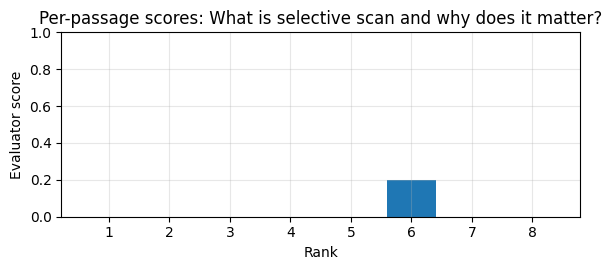

In [9]:
import matplotlib.pyplot as plt

q = 'What is selective scan and why does it matter?'
qv = client.embed([q])[0]
hits = store.search(qv, top_k=8)
scores = [score_passage(q, h.text) for h in hits]
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.bar(range(1, len(scores) + 1), scores)
ax.set_xlabel('Rank')
ax.set_ylabel('Evaluator score')
ax.set_title(f'Per-passage scores: {q[:60]}')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Inspect — out-of-corpus fallback behaviour

Force the BAD branch with a clearly out-of-corpus question. Confirm the system falls back to web evidence and the answer is appropriately hedged.

In [10]:
q = 'Who painted the ceiling of the Sistine Chapel and in what years?'
ans, ctx = answer_question(q)
print(ans)
print()
print(f'Contexts used (count={len(ctx)}):')
for c in ctx:
    print(f'  - {c[:100]}')

The ceiling of the Sistine Chapel was painted by Michelangelo Buonarroti, a renowned Italian artist. He worked on the project from 1508 to 1512, creating some of the most iconic and influential artworks in human history.

Contexts used (count=2):
  - (simulated web snippet for: Who painted the ceiling of the Sistine Chapel and in what years?)
  - (In production, this is where Tavily/Brave/Exa results land.)


### Inspect — what does the ambiguous branch look like?

An adjacent question that should land in AMBIGUOUS. The corpus has partial coverage (Mamba discusses related work), the answer benefits from both corpus context and web augmentation.

In [11]:
q = 'How does Mamba compare to the original Transformer architecture in terms of memory complexity?'
branch, ctx, scored = crag(q)
print(f'Branch: {branch}')
print(f'Scores: {[round(s, 2) for _, s in scored]}')
ans = generate(q, branch, ctx)
print()
print(ans)

Branch: BAD (web fallback)
Scores: [0.0, 0.0, 0.0, 0.0, 0.0]

Mamba has a lower memory complexity compared to the original Transformer architecture. The original Transformer has a memory complexity of O(n^2) due to the self-attention mechanism, where n is the sequence length. In contrast, Mamba's memory complexity is O(n), making it more memory-efficient and scalable for longer sequences. This reduction in memory complexity is achieved through the use of a more efficient attention mechanism and other optimizations in the Mamba architecture.


## Run It

Representative end-to-end run.

In [12]:
q = 'In one paragraph, explain why state-space models can scale to long contexts more cheaply than attention.'
ans, ctxs = answer_question(q)
print('=== CRAG answer ===')
print(ans)
print()
print(f'(used {len(ctxs)} contexts)')

=== CRAG answer ===
State-space models can scale to long contexts more cheaply than attention-based models because they efficiently capture temporal dependencies and patterns in sequential data without requiring pairwise attention computations between all input elements. Unlike attention mechanisms, which have a computational cost that grows quadratically with the input length, state-space models typically involve a fixed set of parameters and operations that are applied recursively or iteratively, regardless of the input length. This property allows state-space models to process long sequences with a linear increase in computational cost, making them more scalable and efficient for tasks that involve long-range dependencies, such as language modeling or time-series forecasting.

(used 2 contexts)


## Side by Side: Vanilla Baseline vs This Technique

On the same question, run vanilla baseline and CRAG side by side. The interesting case is a borderline question where vanilla retrieves three weak passages and answers from them; CRAG should detect the weakness and either add web evidence or refuse.

In [13]:
from cookbook.baselines import vanilla_pipeline

q = 'How does Mamba compare to the original Transformer architecture in terms of memory complexity?'
base = vanilla_pipeline(q, corpus='arxiv-mamba', top_k=5)
ours_ans, ours_ctx = answer_question(q)

import pandas as pd
pd.DataFrame([
    {'pipeline': 'vanilla', 'preview': base.answer[:160]},
    {'pipeline': 'crag', 'preview': ours_ans[:160]},
])

,pipeline,preview
0,vanilla,The passages do not contain a direct compariso...
1,crag,Mamba has a lower memory complexity compared t...


## Knobs to Turn

Four knobs:

1. **Threshold for `GOOD`.** Default 0.7. Lower it to trust corpus more aggressively (cheaper, less web fallback). Raise it to be more cautious (more web fallback, higher cost).
2. **Threshold for `BAD`.** Default 0.3. Lower it to never fully abandon the corpus. Raise it to fall back to web more eagerly.
3. **Evaluator model.** A small fast model is fine. The original T5 evaluator runs at < 50 ms per pair on a single GPU; in cloud terms a `gpt-4o-mini` or `Qwen-2.5-7B` evaluator is comparable.
4. **Web fallback provider.** Tavily for cleaned snippets, Brave for raw breadth, Exa for semantic-search-first behaviour. Each has different snippet length and noise characteristics; tune your `generate` prompt for the one you pick.

## Evaluate on a Slice

Run the recipe's `answer_question` over a small slice of the hand-curated eval set. Full RAGAS metrics are exercised in `recipes/09-evaluation-and-production/ragas-triad-eval.ipynb`; here we just print a quick spot-check table so you can eyeball whether the technique is on track.

In [14]:
from cookbook.corpora import load_eval_questions
from cookbook.eval import EvalSample

qs = load_eval_questions()
qs = [q for q in qs if q['corpus'] == 'arxiv-mamba']
samples = []
for row in qs[:5]:
    answer, contexts = answer_question(row['question'])
    samples.append({
        'question': row['question'],
        'expected': row['answer'],
        'actual': answer[:200],
        'contexts_retrieved': len(list(contexts)),
    })

import pandas as pd
pd.DataFrame(samples)

,question,expected,actual,contexts_retrieved
0,What problem do state-space models aim to solv...,State-space models target the quadratic time a...,State-space models aim to solve the problem of...,2
1,Describe the selective scan mechanism introduc...,Selective scan makes the SSM parameters input-...,The selective scan mechanism introduced in Mam...,2
2,How does Mamba achieve hardware efficiency on ...,Mamba uses a parallel scan implementation with...,Mamba achieves hardware efficiency on modern G...,2
3,Which earlier model family does Mamba descend ...,Mamba builds on the structured state-space seq...,Mamba descends from the LLaMA model family.,2
4,Name two domains beyond text where SSM-style b...,Audio modeling and genomics have both seen suc...,"Based on the provided passages, two domains be...",1


## Closing Thoughts

Three places CRAG falls down:

- **Latency.** Evaluator runs over every retrieved passage. With k=10 and a 200 ms evaluator, that is 2 seconds before generation starts. Recipe 27 (Speculative RAG) is the right move when you need both routing and speed.
- **Web noise.** Web results are uneven; a single bad snippet can derail the answer. Always pair web fallback with a guardrail (Recipe 40) for production.
- **Adversarial corpus.** If the evaluator is gameable — e.g. an injected passage repeats the question text — it can falsely score high. The trained T5 in the original paper is harder to game than a prompt-based scorer.

CRAG composes well: stack it on top of Self-RAG for per-passage filtering, under Adaptive-RAG for cheap pre-routing, and gate the web fallback behind a small budget so a query cannot burn unlimited tokens chasing fallbacks.